In [1]:
import pandas as pd
import seaborn as sns
import os
import warnings
import numpy as np

pd.options.mode.chained_assignment = None # default is 'warn'

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set style
plt.style.use('seaborn-v0_8-paper')

# set sizes
SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 7

rc('font', size=MEDIUM_SIZE)          # controls default text sizes
rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# set font
rc('font', **{'family':'serif','serif':['Arial']})
rc('svg', **{'fonttype':'none'})

# one more change to axes and tick widths
rc('axes', **{'linewidth': 0.5, 'labelpad': 2.5})

rc('xtick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})
rc('ytick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})

In [3]:
########
# Color Schemes and Renames
########

colors_zr_bivalent = [
    "#FFD8A8", "#FFA94D", "#CC5803",
]

colors_zr_k4 = [
    "#cee4f6", "#5095d0", "#367cc0"
]

colors_mean_bivalent_tko = [
    "#bbdca0", "#3A923A", "#01552C"
]

colors_mean_bivalent_dko = [
    '#c2e8f8', '#4b9ed7', '#1253a5',
]

colors_k4 = [
    '#FF6B6B', '#E63946', '#A4161A',
]

titles = {
    'DKO.WGBS_difference': 'DKO − WT WGBS',
    'HUES64_DKO': 'HUES64 DKO WGBS',
    'GSM1112840': 'HUES64 WT WGBS',
    'H3K4me1': 'HUES64 H3K4me1',
    'H3K27me3': 'HUES64 H3K27me3',
    'HUES8_WT.difference': 'TKO − WT WGBS',
    'HUES8_WT_WGBS': 'HUES8 WT WGBS',
    'HUES8_TKO_WGBS': 'HUES8 TKO WGBS'
}

path_out_dir = 'figures'

In [5]:
def load_csv(path_csv):
    
    df = pd.read_csv(path_csv)

    df['bedgraph'] = df['bedgraph'].str.replace('.bedGraph', '', regex=False)

    return df


def plot_lineplots(path_csv, prefix, colors, path_out_dir, promoter_type, order, scale_intragenic=False):

    if isinstance(path_csv, pd.DataFrame):
        df = path_csv
    elif not os.path.exists(path_csv):
        return
    else:
        df = load_csv(path_csv)
    
    if order == 'normal':
        order = [
            f'{promoter_type} Decrease',
            f'{promoter_type} No Change',
            f'{promoter_type} Increase'
        ]
        colors_c = colors
    elif order == 'increase':
        order = [
            f'{promoter_type} No Change',
            f'{promoter_type} Increase'
        ]
        colors_c = colors[1:]
    elif order == 'decrease':
        order = [
            f'{promoter_type} Decrease',
            f'{promoter_type} No Change'
        ]
        colors_c = colors[:2]
    elif order == None:
        order = [region for region in list(set(df['region'])) if promoter_type in region and 'nan' not in region]
        order.sort()
        colors_c = colors
    else:
        colors_c = colors

    df = df.loc[df['region'].str.contains(promoter_type)].copy()
    
    bedgraphs = list(set(list(df['bedgraph'])))
    
    for bedgraph in bedgraphs:

        if 'H3K36me3' in bedgraph or 'H3K9ac' in bedgraph or 'H3K9me3' in bedgraph or 'H3K4me3' in bedgraph:
            continue

        if 'normlog2' in bedgraph or 'normsubtract' in bedgraph:
            continue
        
        print(prefix, bedgraph)
        
        df_filt = df.loc[df['bedgraph'] == bedgraph]

        '''
        print(df_filt.groupby('region')['position'].min())

        # Check if it's a consistent offset
        print(df_filt.groupby('region')['position'].agg(['min', 'max', 'count']))
        
        # See if the spacing between positions is consistent
        for region in df_filt['region'].unique():
            positions = df_filt[df_filt['region'] == region]['position'].unique()
            positions = np.sort(positions)
            diffs = np.diff(positions)
            print(f"{region}: spacing = {diffs[:5]}")  # Check first few intervals
        '''

        start = -10000.0
        interval = 80.31726908
        
        df_filt['position'] = start + ((df_filt['position'] - start) / interval).round() * interval
        
        fig, ax = plt.subplots()
        #fig.set_size_inches(4, 4)
        fig.set_size_inches(1, 1)
    
        ax = sns.lineplot(
            data=df_filt,
            x='position',
            y='value',
            hue='region',
            hue_order=order,
            palette=colors_c,
            ax=ax,
            lw=0.5,
            estimator='mean',
            errorbar="ci",
            legend=False
        )
        #sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

        title = bedgraph
        for key, value in titles.items():
            if key in bedgraph:
                title = value
                break
        ax.set_title(title)

        if not scale_intragenic:
            x_labels = ax.get_xticks()
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=UserWarning)
                ax.set_xticklabels([f'{int(x/1000)}kb' for x in x_labels])
        
        ax.set_xlabel('Position relative to TSS')
    
        if 'difference' in bedgraph:
            ax.set_ylabel('Δ Meth. ratio')
            if 'dko' in prefix:
                ax.set_ylim(-0.4, 0.01)
            elif 'tko' in prefix:
                nun=1
                ax.set_ylim(-0.02, 0.21)
        elif 'WGBS' in bedgraph:
            ax.set_ylabel('Meth. ratio')
            ax.set_ylim(0, 1)
        else:
            ax.set_ylabel('ChIP-seq')

        if 'H3K27me3' in bedgraph:
            ax.set_ylim(1, 14)
        elif 'H3K36me3' in bedgraph:
            ax.set_ylim(0.7, 1.7)
        elif 'H3K4me1' in bedgraph:
            ax.set_ylim(1, 2.5)
        elif 'DNMT3A' in bedgraph:
            ax.set_ylim(1.1, 1.9)
        elif 'DNMT3B' in bedgraph:
            ax.set_ylim(0.7, 1.8)
        elif 'TET1-V5' in bedgraph:
            ax.set_ylim(1, 20)
        
        path_svg = os.path.join(path_out_dir, f'{prefix}_{promoter_type}_{bedgraph}.svg')
        
        plt.savefig(path_svg)
        
        plt.show()
        
        plt.close('all')

/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth/smooth_histone_wtmean.csv
wt_mean HUES64_H3K9me3.mLb.clN.sorted.bam.normratio


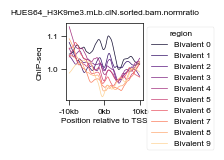

wt_mean HUES64_H3K9ac.mLb.clN.sorted.bam.normratio


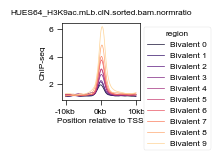

wt_mean HUES64_H3K4me3.mLb.clN.sorted.bam.normratio


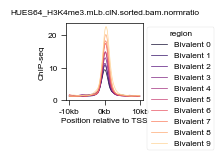

wt_mean HUES64_H3K27me3.mLb.clN.sorted.bam.normratio


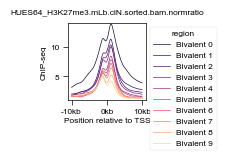

wt_mean HUES64_H3K4me1.mLb.clN.sorted.bam.normratio


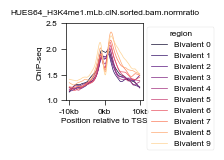

wt_mean HUES64_H3K36me3.mLb.clN.sorted.bam.normratio


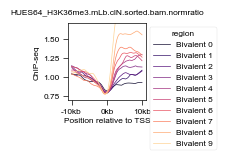

In [14]:
paths_csv_wtmean = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth/smooth_histone_wtmean.csv'
]

for path_csv in paths_csv_wtmean:
    plot_lineplots(path_csv, 'wt_mean', "magma", path_out_dir, 'Bivalent', None, scale_intragenic=False)

    

        Unnamed: 0  index                                         bedgraph  \
0                0      0       HUES64_H3K4me1.mLb.clN.sorted.bam.normlog2   
1                1      1       HUES64_H3K4me1.mLb.clN.sorted.bam.normlog2   
2                2      2       HUES64_H3K4me1.mLb.clN.sorted.bam.normlog2   
3                3      3       HUES64_H3K4me1.mLb.clN.sorted.bam.normlog2   
4                4      4       HUES64_H3K4me1.mLb.clN.sorted.bam.normlog2   
...            ...    ...                                              ...   
206995        8995    245  HUES64_H3K36me3.mLb.clN.sorted.bam.normsubtract   
206996        8996    246  HUES64_H3K36me3.mLb.clN.sorted.bam.normsubtract   
206997        8997    247  HUES64_H3K36me3.mLb.clN.sorted.bam.normsubtract   
206998        8998    248  HUES64_H3K36me3.mLb.clN.sorted.bam.normsubtract   
206999        8999    249  HUES64_H3K36me3.mLb.clN.sorted.bam.normsubtract   

                                        region      position   

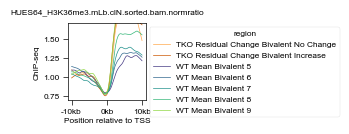

wt_mean_and_res HUES64_H3K4me3.mLb.clN.sorted.bam.normratio


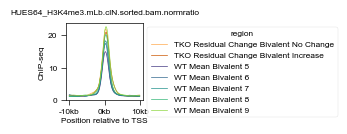

wt_mean_and_res HUES64_H3K9me3.mLb.clN.sorted.bam.normratio


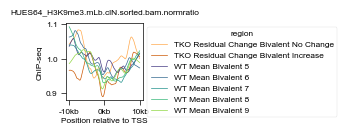

wt_mean_and_res HUES64_H3K9ac.mLb.clN.sorted.bam.normratio


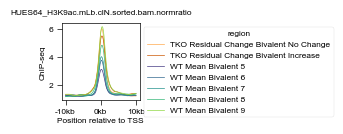

wt_mean_and_res HUES64_H3K27me3.mLb.clN.sorted.bam.normratio


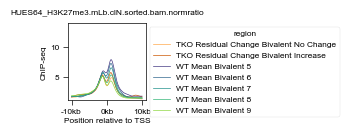

wt_mean_and_res HUES64_H3K4me1.mLb.clN.sorted.bam.normratio


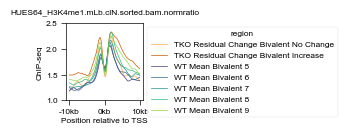

In [26]:
# combine mean and residual

path_csv_wtmean = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth/smooth_histone_wtmean.csv'
path_csv_res = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth/filter/smooth_histone_hues64_tko_biv_filtmeannoc_matchresinc.csv'

df_wtmean = load_csv(path_csv_wtmean)

df_wtmean['region'] = 'WT Mean ' + df_wtmean['region']

df_res = load_csv(path_csv_res)

df_res['region'] = 'TKO Residual Change ' + df_res['region']

df = pd.concat([df_wtmean, df_res], ignore_index=True)

order = [
    'TKO Residual Change Bivalent No Change',
    'TKO Residual Change Bivalent Increase',
    'WT Mean Bivalent 5',
    'WT Mean Bivalent 6',
    'WT Mean Bivalent 7',
    'WT Mean Bivalent 8',
    'WT Mean Bivalent 9',
]

viridis_5 = sns.color_palette('viridis', 5)

colors = ["#FFA94D", "#CC5803"] + viridis_5

plot_lineplots(df, 'wt_mean_and_res', colors, path_out_dir, 'Bivalent', order, scale_intragenic=False)


/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth_dko/smooth_wgbs_diff_dko_wt_mean_cutoffs_intragenic.csv
dko_mean_intragenic GSM1112840.HUES64.WGBS_GSM3662265.HUES64_DKO.WGBS_difference


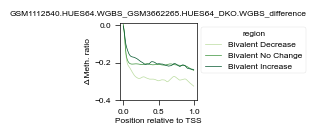

/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth_dko/smooth_wgbs_diff_dko_wt_zr_cutoffs_intragenic.csv
dko_zr_intragenic GSM1112840.HUES64.WGBS_GSM3662265.HUES64_DKO.WGBS_difference


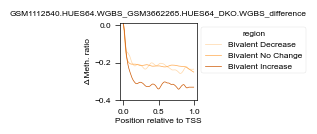

In [5]:
# DKO ZR
prefix_dko_gene = 'dko_zr_intragenic'
#,
paths_csv_dko_gene = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth_dko/smooth_wgbs_diff_dko_wt_mean_cutoffs_intragenic.csv',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth_dko/smooth_wgbs_diff_dko_wt_zr_cutoffs_intragenic.csv',
    
]

for path_csv in paths_csv_dko_gene:

    if 'zr' in path_csv:
        prefix = 'dko_zr_intragenic'
    else:
        prefix = 'dko_mean_intragenic'
    
    if 'zr' in path_csv:
        colors = colors_zr_bivalent
    else:
        colors = colors_mean_bivalent
        
    plot_lineplots(path_csv, prefix, colors, path_out_dir, 'Bivalent', scale_intragenic=True)

    if 'zr' in path_csv:
        colors = colors_zr_k4
    else:
        colors = colors_mean_k4
        
    #plot_lineplots(path_csv, prefix, colors, path_out_dir, 'H3K4me3', scale_intragenic=True)


tko_biv_filtresnoc_matchmeaninc GSM3618720_HUES8_TKO.GSM3618718_HUES8_WT.difference


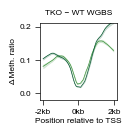

tko_biv_filtresnoc_matchmeandec GSM3618720_HUES8_TKO.GSM3618718_HUES8_WT.difference


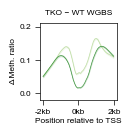

tko_k4_filtnone_matchmeaninc GSM3618720_HUES8_TKO.GSM3618718_HUES8_WT.difference


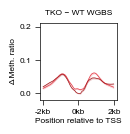

tko_k4_filtnone_matchmeandec GSM3618720_HUES8_TKO.GSM3618718_HUES8_WT.difference


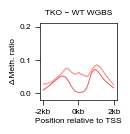

In [6]:
path_root = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth/filter_zoom'

all_filter_types = {
	"tko_biv_filtresnoc_matchmeaninc": colors_mean_bivalent_tko,
	"tko_biv_filtresnoc_matchmeandec": colors_mean_bivalent_tko,
	"tko_k4_filtnone_matchmeaninc": colors_k4,
	"tko_k4_filtnone_matchmeandec": colors_k4
}

for filter_type, colors  in all_filter_types.items():

    if filter_type[-3:] == 'inc':
        filter_type_long = 'increase'
    else:
        filter_type_long = 'decrease'

    if 'biv' in filter_type:
        promoter_type = 'Bivalent'
    else:
        promoter_type = 'H3K4me3'
    
    paths_csv_tko = [
        f'{path_root}/smooth_wgbs_diff_{filter_type}.csv',
        f'{path_root}/smooth_tko_wgbs_{filter_type}.csv',
        f'{path_root}/smooth_wt_wgbs_{filter_type}.csv',
        f'{path_root}/smooth_histone_hues64_{filter_type}.csv'
    ]

    for path_csv in paths_csv_tko:

        dfs = [load_csv(path_csv.replace('.csv', f'_{i}.csv')) for i in range(10) if os.path.exists(path_csv.replace('.csv', f'_{i}.csv'))]

        if dfs:
            
            df_concat = pd.concat(dfs, ignore_index=True)
        
            plot_lineplots(df_concat, filter_type, colors, path_out_dir, promoter_type, filter_type_long)

tko_biv_filtnone_matchmeaninc GSM3618720_HUES8_TKO.GSM3618718_HUES8_WT.difference


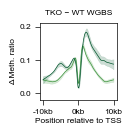

tko_biv_filtnone_matchmeaninc GSM3618720_HUES8_TKO_WGBS


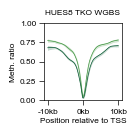

tko_biv_filtnone_matchmeaninc GSM3618718_HUES8_WT_WGBS


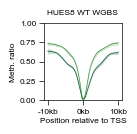

tko_biv_filtnone_matchmeaninc HUES64_H3K27me3.mLb.clN.sorted.bam.normratio


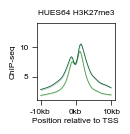

tko_biv_filtnone_matchmeaninc HUES64_H3K4me1.mLb.clN.sorted.bam.normratio


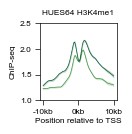

tko_biv_filtnone_matchmeandec GSM3618720_HUES8_TKO.GSM3618718_HUES8_WT.difference


In [ ]:
path_root = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth/filter'

all_filter_types = {
    "tko_biv_filtnone_matchmeaninc": colors_mean_bivalent_tko,
	"tko_biv_filtnone_matchmeandec": colors_mean_bivalent_tko,
    "tko_biv_filtnone_matchresinc": colors_zr_bivalent,
    "tko_biv_filtnone_matchresdec": colors_zr_bivalent,
	"tko_biv_filtresnoc_matchmeaninc": colors_mean_bivalent_tko,
	"tko_biv_filtresnoc_matchmeandec": colors_mean_bivalent_tko,
	"tko_biv_filtmeannoc_matchresinc": colors_zr_bivalent,
	"tko_k4_filtnone_matchmeaninc": colors_k4,
	"tko_k4_filtnone_matchmeandec": colors_k4
}

for filter_type, colors  in all_filter_types.items():

    if filter_type[-3:] == 'inc':
        filter_type_long = 'increase'
    else:
        filter_type_long = 'decrease'

    if 'biv' in filter_type:
        promoter_type = 'Bivalent'
    else:
        promoter_type = 'H3K4me3'
    
    paths_csv_tko = [
        f'{path_root}/smooth_wgbs_diff_{filter_type}.csv',
        f'{path_root}/smooth_tko_wgbs_{filter_type}.csv',
        f'{path_root}/smooth_wt_wgbs_{filter_type}.csv',
        f'{path_root}/smooth_histone_hues64_{filter_type}.csv'
    ]

    for path_csv in paths_csv_tko:

        dfs = [load_csv(path_csv.replace('.csv', f'_{i}.csv')) for i in range(10) if os.path.exists(path_csv.replace('.csv', f'_{i}.csv'))]

        if dfs:
            
            df_concat = pd.concat(dfs, ignore_index=True)
        
            plot_lineplots(df_concat, filter_type, colors, path_out_dir, promoter_type, filter_type_long)
    

dko_biv_filtnone_matchmeaninc GSM1112840.HUES64.WGBS_GSM3662265.HUES64_DKO.WGBS_difference


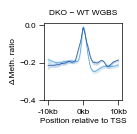

dko_biv_filtnone_matchmeaninc GSM3662265_HUES64_DKO_P28_WGBS


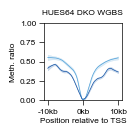

dko_biv_filtnone_matchmeaninc GSM1112840_BI.HUES64.Bisulfite-Seq.WGBS_Lib_26


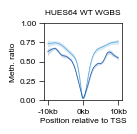

dko_biv_filtnone_matchmeaninc HUES64_H3K27me3.mLb.clN.sorted.bam.normratio


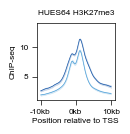

dko_biv_filtnone_matchmeaninc HUES64_H3K4me1.mLb.clN.sorted.bam.normratio


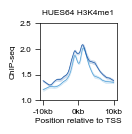

dko_biv_filtnone_matchmeandec GSM1112840.HUES64.WGBS_GSM3662265.HUES64_DKO.WGBS_difference


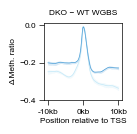

dko_biv_filtnone_matchmeandec GSM3662265_HUES64_DKO_P28_WGBS


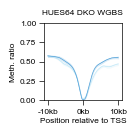

dko_biv_filtnone_matchmeandec GSM1112840_BI.HUES64.Bisulfite-Seq.WGBS_Lib_26


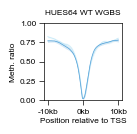

dko_biv_filtnone_matchmeandec HUES64_H3K27me3.mLb.clN.sorted.bam.normratio


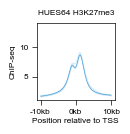

dko_biv_filtnone_matchmeandec HUES64_H3K4me1.mLb.clN.sorted.bam.normratio


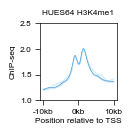

dko_k4_filtnone_matchmeaninc GSM1112840.HUES64.WGBS_GSM3662265.HUES64_DKO.WGBS_difference


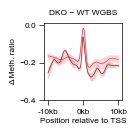

dko_k4_filtnone_matchmeaninc GSM3662265_HUES64_DKO_P28_WGBS


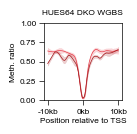

dko_k4_filtnone_matchmeaninc GSM1112840_BI.HUES64.Bisulfite-Seq.WGBS_Lib_26


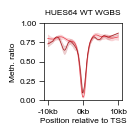

dko_k4_filtnone_matchmeaninc HUES64_H3K27me3.mLb.clN.sorted.bam.normratio


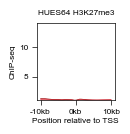

dko_k4_filtnone_matchmeaninc HUES64_H3K4me1.mLb.clN.sorted.bam.normratio


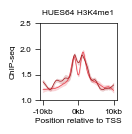

dko_k4_filtnone_matchmeandec GSM1112840.HUES64.WGBS_GSM3662265.HUES64_DKO.WGBS_difference


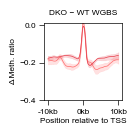

dko_k4_filtnone_matchmeandec GSM3662265_HUES64_DKO_P28_WGBS


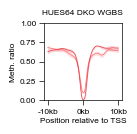

dko_k4_filtnone_matchmeandec GSM1112840_BI.HUES64.Bisulfite-Seq.WGBS_Lib_26


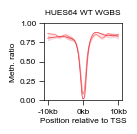

dko_k4_filtnone_matchmeandec HUES64_H3K27me3.mLb.clN.sorted.bam.normratio


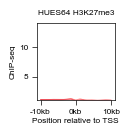

dko_k4_filtnone_matchmeandec HUES64_H3K4me1.mLb.clN.sorted.bam.normratio


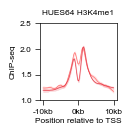

In [6]:
path_root = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth_dko/filter'

all_filter_types = {
	"dko_biv_filtnone_matchmeaninc": colors_mean_bivalent_dko,
	"dko_biv_filtnone_matchmeandec": colors_mean_bivalent_dko,
	"dko_k4_filtnone_matchmeaninc": colors_k4,
	"dko_k4_filtnone_matchmeandec": colors_k4
}

for filter_type, colors  in all_filter_types.items():

    if filter_type[-3:] == 'inc':
        filter_type_long = 'increase'
    else:
        filter_type_long = 'decrease'

    if 'biv' in filter_type:
        promoter_type = 'Bivalent'
    else:
        promoter_type = 'H3K4me3'
    
    paths_csv_tko = [
        f'{path_root}/smooth_wgbs_diff_dko_wt_{filter_type}.csv',
        f'{path_root}/smooth_dko_wgbs_{filter_type}.csv',
        f'{path_root}/smooth_wt_wgbs_{filter_type}.csv',
        f'{path_root}/smooth_histone_hues64_{filter_type}.csv'
    ]

    for path_csv in paths_csv_tko:

        dfs = [load_csv(path_csv.replace('.csv', f'_{i}.csv')) for i in range(10) if os.path.exists(path_csv.replace('.csv', f'_{i}.csv'))]

        if dfs:
            
            df_concat = pd.concat(dfs, ignore_index=True)
        
            plot_lineplots(df_concat, filter_type, colors, path_out_dir, promoter_type, filter_type_long)

mean GSM3618720_HUES8_TKO.GSM3618718_HUES8_WT.difference


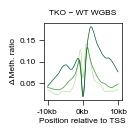

mean GSM3618720_HUES8_TKO_WGBS


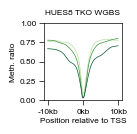

mean GSM3618718_HUES8_WT_WGBS


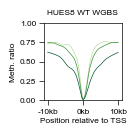

mean HUES64_H3K27me3.mLb.clN.sorted.bam.normratio


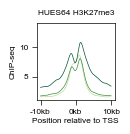

mean HUES64_H3K4me1.mLb.clN.sorted.bam.normratio


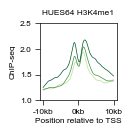

res GSM3618720_HUES8_TKO.GSM3618718_HUES8_WT.difference


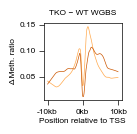

res GSM3618720_HUES8_TKO_WGBS


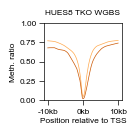

res GSM3618718_HUES8_WT_WGBS


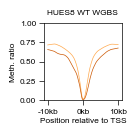

res HUES64_H3K27me3.mLb.clN.sorted.bam.normratio


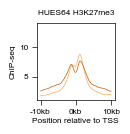

res HUES64_H3K4me1.mLb.clN.sorted.bam.normratio


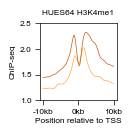

In [6]:
path_root = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/smooth'

all_filter_types = {
    "mean": colors_mean_bivalent_tko,
    "res": colors_zr_bivalent
}

for filter_type, colors  in all_filter_types.items():
    
    paths_csv_tko = [
        f'{path_root}/smooth_wgbs_diff_{filter_type}.csv',
        f'{path_root}/smooth_tko_wgbs_{filter_type}.csv',
        f'{path_root}/smooth_wt_wgbs_{filter_type}.csv',
        f'{path_root}/smooth_histone_hues64_{filter_type}.csv'
    ]

    for path_csv in paths_csv_tko:
            
        df = load_csv(path_csv)

        if filter_type == 'res':
            which_to_plot = 'increase'
        else:
            which_to_plot = 'normal'
            
        plot_lineplots(df, filter_type, colors, path_out_dir, 'Bivalent', which_to_plot)
    